Loading data from file: UVFIBERX-455 -> UVFIBERX-455.csv
Loading data from file: BBFIBERX-600 -> BBFIBERX-600.csv


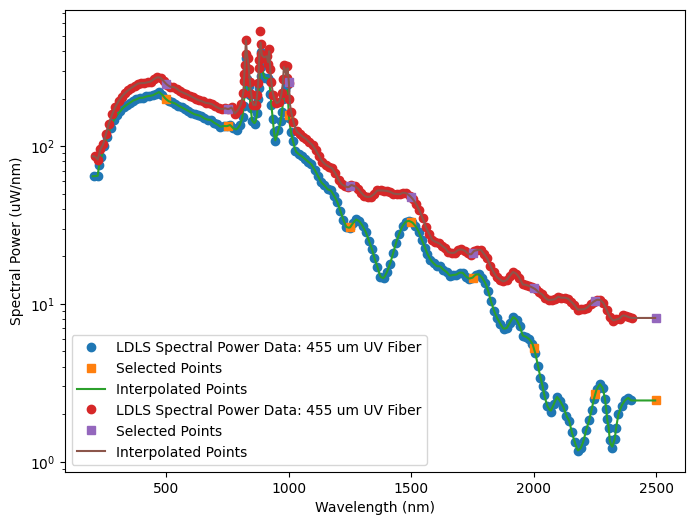

In [1]:
# Import the light source spectral power data

import numpy as np
import matplotlib.pyplot as plt

# load data 
datafiles = {"UVFIBERX-455" : "UVFIBERX-455.csv",
             "BBFIBERX-600" : "BBFIBERX-600.csv",}


fig, ax = plt.subplots(figsize=(8,6))
wavelengths = np.arange(200, 2500, 5)

ldls_spectral_power_dict = {}

for datafile_key in datafiles:
    datafile = datafiles[datafile_key]
    print(f"Loading data from file: {datafile_key} -> {datafile}")
    ldls_raw_wavelength, ldls_raw_spectral_power = np.loadtxt(datafile, delimiter=',', skiprows=1, unpack = True)
    # make sure we sort so wavelengths are increasing
    sort_inds = np.argsort(ldls_raw_wavelength)
    ldls_raw_wavelength = ldls_raw_wavelength[sort_inds]
    ldls_raw_spectral_power = ldls_raw_spectral_power[sort_inds]


    # plot the data
    ax.semilogy(ldls_raw_wavelength, ldls_raw_spectral_power, 'o', label = "LDLS Spectral Power Data: 455 um UV Fiber")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Spectral Power (uW/nm)") 

    # interpolate to get spectral power at desired wavelengths

    ldls_spectral_power_interp = np.interp(wavelengths, ldls_raw_wavelength, ldls_raw_spectral_power)

    selected_wavelengths = np.array([500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500])
    selected_spectral_powers = np.interp(selected_wavelengths, ldls_raw_wavelength, ldls_raw_spectral_power)
    ax.semilogy(selected_wavelengths, selected_spectral_powers, 's', label = "Selected Points")

    # update the raw spectal power dict with : wavelengths and interpolated spectral power
    ldls_spectral_power_dict[datafile_key] = {"wavelengths_nm": wavelengths,
                                              "spectral_power_uW_per_nm": ldls_spectral_power_interp}

    ax.semilogy(wavelengths, ldls_spectral_power_interp, '-', label = "Interpolated Points")
ax.legend()
plt.show()

/Users/nlourie/Desktop/Work/MIT/Optical Testing/GIT/optical-testing-analysis-tools/characterization/winter


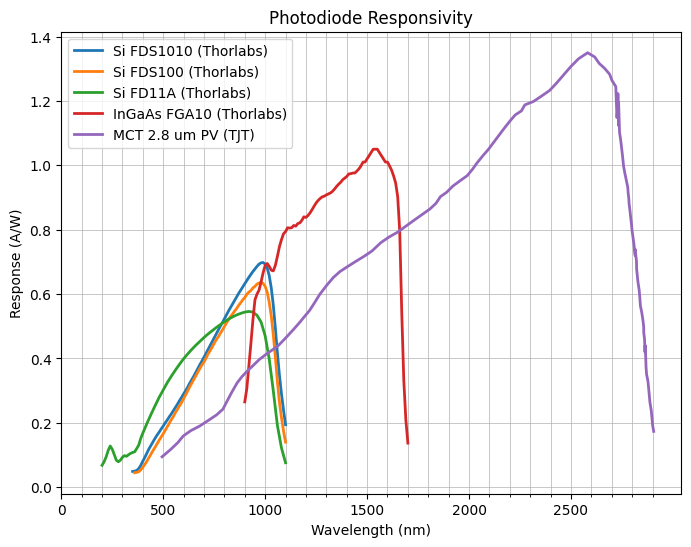

In [13]:
# Photodiodes
import os
global c
c = 2.998 * 10 ** 10 # speed of light in cm/s
global h
h = 6.626 * 10 ** -27 # Planck's constant in g cm^2/s

class CalibratedPD(object):
    '''A class to represent a calibrated photodiode.
    
    Attributes:
    ------------
    filename : str
        The complete path to the FITS or csv file containing the calibrated
        photodiode response. The data should have three columns:
        wavelength (nm), response (A/W), and uncertainty in response
        (percent).
    response : numpy.ndarray
        The calibrated photodiode response. First column is
        wavelength in nm, second column is response in A/W. Third
        column is uncertainty in response, in percent.
    area : float
        The area of the photodiode active area, in cm^2.
    plot : bool
        If True, a plot of the response will be generated.
    ax: matplotlib.axes.Axes
        The axes object for the plot, if plot is True.
    name: str
        The name of the photodiode.
    '''
    def __init__(self, filename, area_cm2, plot=False, ax = None, name=""):
        self.response = np.genfromtxt(filename, delimiter=',')
        self.area_cm2 = area_cm2
        self.area_mm2 = area_cm2 * 100  # convert to mm^2
        self.plot = plot
        self.ax = ax
        self.name = name
        if plot:
            self.plot_response()

    def plot_response(self):
        '''Plot the calibrated photodiode response.'''
        if self.ax is not None:
            ax = self.ax
        else:   
            fig, ax = plt.subplots()
        """
        # if there are more than 2 columns, assume the third column is uncertainty in percent
        if self.response.shape[1] > 2:
            errors = self.response[:,2] * self.response[:,1] / 100
            ax.errorbar(self.response[:,0], self.response[:,1],
                        yerr=errors, fmt='o', label = self.name)
        else:
            ax.plot(self.response[:,0], self.response[:,1], 'o', label = self.name)
        """
        ax.plot(self.response[:,0], self.response[:,1], '-', linewidth=2, label = self.name)
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('Response (A/W)')
        if self.ax is None:
            ax.set_title('Photodiode Response')
            plt.show()

    def get_response(self, wavelength):
        '''Returns the calibrated photodiode response at a given wavelength.'''
        #plot_wavelength = np.linspace(np.min(self.response[:,0]), np.max(self.response[:,0]), 1000)
        response = np.interp(wavelength, self.response[:,0], self.response[:,1])
        return response
    
photodiodes = {}
fig, ax = plt.subplots(figsize=(8,6))
data_dir = os.path.join(os.path.dirname(os.getcwd()), "characterization", "winter")
print(data_dir)
si_fds1010_pd_filename = os.path.join(data_dir, 'ThorLabsPD.csv')
si_fds1010_pd_area_cm2 = 1  # Thorlabs active area is 1 cm^2
si_fds1010_pd = CalibratedPD(si_fds1010_pd_filename, si_fds1010_pd_area_cm2, plot=True, ax=ax, name="Si FDS1010 (Thorlabs)")
photodiodes['Si_FDS1010'] = si_fds1010_pd

si_fds100_pd_filename = os.path.join(data_dir, 'fds100_photodiode_responsivity.csv')
si_fds_pd_area_mm2 = 3.6**2 # Si FDS100 active area is 3.6 mm x 3.6 mm
si_fds_pd_area_cm2 = si_fds_pd_area_mm2 / 100  # convert to cm^2
si_fds100_pd = CalibratedPD(si_fds100_pd_filename, si_fds_pd_area_cm2, plot=True, ax=ax, name="Si FDS100 (Thorlabs)")
photodiodes['Si_FDS100'] = si_fds100_pd

si_fd11a_pd_filename = os.path.join(data_dir, "si_fd11a_photodiode_responsivity.csv")
si_fd11a_pd_area_mm2 = 1.1**2  # Si FD11A active area is 1.1 mm x 1.1 mm
si_fd11a_pd_area_cm2 = si_fd11a_pd_area_mm2 / 100  # convert to cm^2
si_fd11a_pd = CalibratedPD(si_fd11a_pd_filename, si_fd11a_pd_area_cm2, plot=True, ax=ax, name="Si FD11A (Thorlabs)")
photodiodes['Si_FD11A'] = si_fd11a_pd

ingaas_fga10_pd_filename = os.path.join(data_dir, 'InGaAs_FGA10_PD.csv')
ingaas_fga10_pd_area_mm2 = 1  # InGaAs FGA10 active area is 1 mm^2
ingaas_fga10_pd_area_cm2 = ingaas_fga10_pd_area_mm2 / 100  # convert to cm^2
ingaas_fga10_pd = CalibratedPD(ingaas_fga10_pd_filename, ingaas_fga10_pd_area_cm2, plot=True, ax=ax, name="InGaAs FGA10 (Thorlabs)")
photodiodes['InGaAs_FGA10'] = ingaas_fga10_pd

tjt_mct_pd_area_mm2 = 1  # TJT MCT active area is 1 mm^2
tjt_mct_pd_area_cm2 = tjt_mct_pd_area_mm2 / 100  # convert to cm^2
tjt_mct_pd_filename = os.path.join(data_dir, "TJT_PV_MCT_2.8um_Cutoff_Responsivity.csv")
tjt_mct_pd = CalibratedPD(tjt_mct_pd_filename, tjt_mct_pd_area_cm2, plot=True, ax=ax, name="MCT 2.8 um PV (TJT)")
photodiodes['MCT_TJT'] = tjt_mct_pd

ax.legend()
ax.set_title('Photodiode Responsivity')
# want major grid lines every 500 nm, minor every 100 nm
ax.set_xticks(np.arange(0, 3000, 500))
ax.set_xticks(np.arange(0, 3000, 100), minor=True)
ax.grid(True, which='both', linewidth=0.5)

In [ ]:
pd = 'MCT_TJT'  # options: 'Si_FDS1010
photodiodes[pd].get_response(700)

Port fraction: 0.023
Sphere multiplier: 23.060
Wavelength: 500 nm, electrons per second on pixel: 4.69e-01 e-/s
Wavelength: 750 nm, electrons per second on pixel: 4.88e-01 e-/s
Wavelength: 1000 nm, electrons per second on pixel: 9.68e-01 e-/s
Wavelength: 1250 nm, electrons per second on pixel: 2.64e-01 e-/s
Wavelength: 1500 nm, electrons per second on pixel: 2.68e-01 e-/s
Wavelength: 1750 nm, electrons per second on pixel: 1.40e-01 e-/s
Wavelength: 2000 nm, electrons per second on pixel: 9.49e-02 e-/s
Wavelength: 2250 nm, electrons per second on pixel: 8.90e-02 e-/s
Wavelength: 2500 nm, electrons per second on pixel: 7.69e-02 e-/s


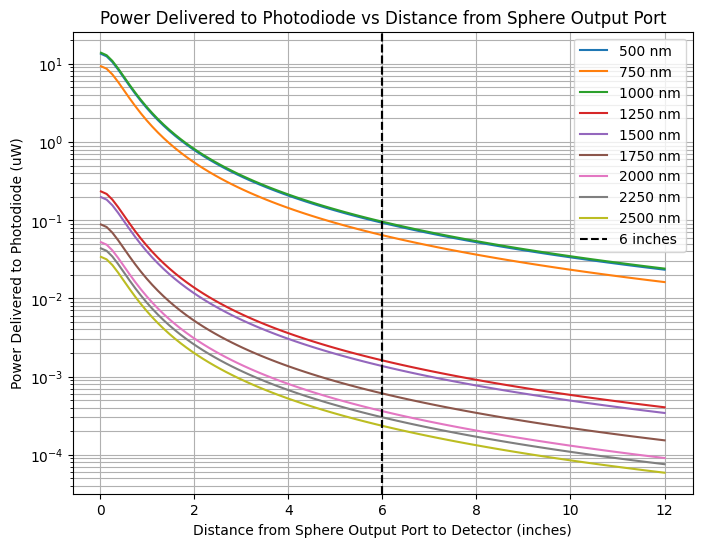

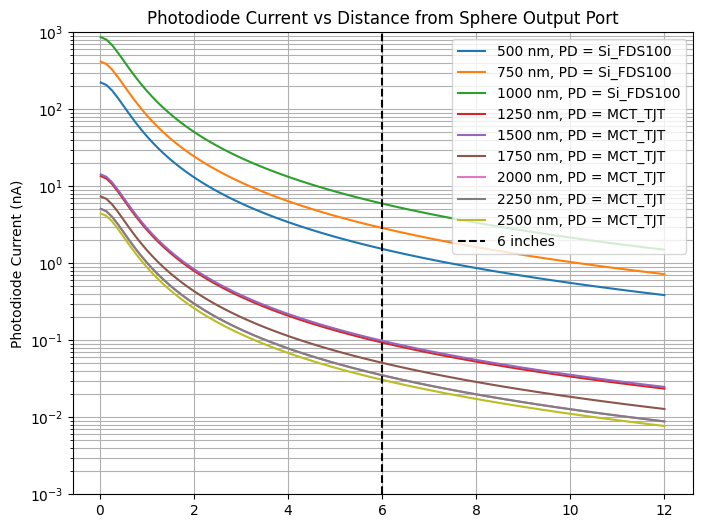

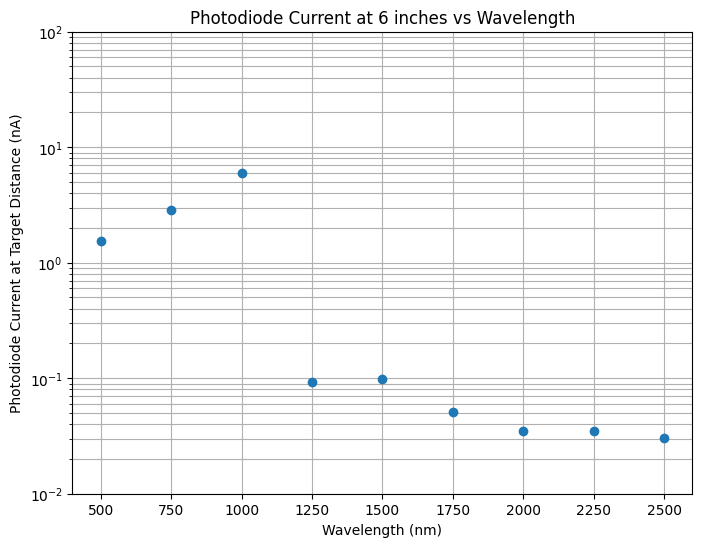

In [32]:
# Integrating sphere parameters

rho = 0.98  # reflectivity of sphere inner surface
dia_sphere_in = 3.3  # diameter of sphere in inches
dia_port_in = 1.0  # diameter of input port in inches

dia_sphere_mm = dia_sphere_in * 25.4  # convert to mm
dia_port_mm = dia_port_in * 25.4  # convert to mm

A_sphere_mm2 = np.pi * (dia_sphere_mm/2)**2  # cross-sectional area of sphere in mm^2

n_ports = 1  # number of ports (input + output)
f = (n_ports/4) * (dia_port_in/dia_sphere_in)**2  # port fraction
print(f"Port fraction: {f:.3f}")

M = rho / (1 - rho*(1-f)) # sphere multiplier
print(f"Sphere multiplier: {M:.3f}")

# Input Power: Phi_i
# Ls : Luminance of sphere
# As : Area of sphere (total)
# Ls = Phi_i * M / (pi*As)
# Phi_d : Power delivered to detector
# Ad : Area of detector
# theta : half-angle subtended by the sphere port as seen from the detector
# Phi_d = Ls * Ad * Pi * sin^2(theta)

dist_detector_mm_arr = np.linspace(0.5, 12*25.4, 100)  # distance from output port to detector in mm
target_distance_in = 6  # target distance in inches
target_distance_mm = target_distance_in * 25.4  # convert to mm
dist_detector_mm_arr = np.append(dist_detector_mm_arr, target_distance_mm)
theta_arr = np.arctan((dia_port_mm/2) / dist_detector_mm_arr)  # half-angle in radians

# Photodiode detector parameters
# which photodiode

ldls_fiber = "BBFIBERX-600"  # options: "UVFIBERX-455", "BBFIBERX-600"



fig_power, ax_power = plt.subplots(figsize=(8,6))
fig_current, ax_current = plt.subplots(figsize=(8,6))

throughput_correction = 0.1  # measured throughput loss factor

current_at_target_distance = []

for wavelength in selected_wavelengths:

    # which photodiode?
    if wavelength < 1050:
        pd = 'Si_FDS100'
    #elif (wavelength >= 1050) and (wavelength < 1650):
    #    pd = 'InGaAs_FGA10'
    else:
        pd = 'MCT_TJT'

    A_pd_mm2 = photodiodes[pd].area_mm2  # area of photodiode active area in mm^2

    A_detector_pixel_mm2 = .015**2  # area of detector in mm^2 (e.g., 15 um pixel)
    spectral_bandwidth = 10  # nm, assume 10 nm bandwidth for calculation

    # get spectral power at this wavelength
    ldls_raw_wavelength = ldls_spectral_power_dict[ldls_fiber]["wavelengths_nm"]
    ldls_raw_spectral_power = ldls_spectral_power_dict[ldls_fiber]["spectral_power_uW_per_nm"]
    
    spectral_power = np.interp(wavelength, ldls_raw_wavelength, ldls_raw_spectral_power)  # uW/nm
    #print(f"Wavelength: {wavelength} nm, Spectral Power: {spectral_power:.2f} uW/nm")

    phi_i = spectral_power * spectral_bandwidth * throughput_correction  # total input power in uW

    Ls_arr = phi_i * M / (np.pi * A_sphere_mm2)  # sphere luminance in uW/mm^2/sr

    # Calculate power delivered to photodiode detector
    phi_d_arr_uW = Ls_arr * A_pd_mm2 * np.pi * (np.sin(theta_arr))**2  # power delivered to detector in uW

    # Calculate the power delivered to the detector pixel
    phi_d_pixel_arr_uW = Ls_arr * A_detector_pixel_mm2 * np.pi * (np.sin(theta_arr))**2  # power delivered to detector pixel in uW
    # photons_per_second = optical power (W) / energy per photon (J)
    e_photon_J = (h * c) / (wavelength * 1e-9)  # energy per photon in Joules (wavelength converted to m)
    photons_per_second = phi_d_pixel_arr_uW * 1e-6 / e_photon_J  # convert uW to W
    QE = 0.8  # assume 80% quantum efficiency
    electrons_per_second = photons_per_second * QE  # accounting for quantum efficiency
    print(f"Wavelength: {wavelength} nm, electrons per second on pixel: {electrons_per_second[0]:.2e} e-/s")


    # Calculate the photodiode response at this wavelength
    i_pd = (phi_d_arr_uW*1e-6)*photodiodes[pd].get_response(wavelength) * throughput_correction  # A/W


    ax_power.plot(dist_detector_mm_arr[:-1]/25.4, phi_d_arr_uW[:-1], label = f"{wavelength} nm")
    ax_current.plot(dist_detector_mm_arr[:-1]/25.4, i_pd[:-1]*1e9, label = f"{wavelength} nm, PD = {pd}")  # convert A to nA

    # store current @ target wavelength (last one)
    current_at_target_distance.append(i_pd[-1] * 1e9)  # convert A to nA
    

    

ax_power.axvline(x=6, color='k', linestyle='--', label='6 inches')
ax_power.set_xlabel("Distance from Sphere Output Port to Detector (inches)")
ax_power.set_ylabel("Power Delivered to Photodiode (uW)")
ax_power.set_title("Power Delivered to Photodiode vs Distance from Sphere Output Port")
ax_power.set_yscale('log')
ax_power.legend()
ax_power.grid(True, which = 'both')

ax_power.axvline(x=target_distance_in, color='k', linestyle='--', label=f'{target_distance_in} inches')
ax_current.axvline(x=target_distance_in, color='k', linestyle='--', label=f'{target_distance_in} inches')
ax_current.set_ylabel("Photodiode Current (nA)")
ax_current.set_title("Photodiode Current vs Distance from Sphere Output Port")
ax_current.set_ylim(1e-3, 1e3)
ax_current.set_yscale('log')
ax_current.legend()
ax_current.grid(True, which = 'both')


# Plot the photocurrent at target distance against wavelength @ target distance
fig_current_vs_wavelength, ax_current_vs_wavelength = plt.subplots(figsize=(8,6))
ax_current_vs_wavelength.semilogy(selected_wavelengths, current_at_target_distance, 'o')
ax_current_vs_wavelength.set_xlabel("Wavelength (nm)")
ax_current_vs_wavelength.set_ylabel("Photodiode Current at Target Distance (nA)")
ax_current_vs_wavelength.set_title(f"Photodiode Current at {target_distance_in} inches vs Wavelength")
ax_current_vs_wavelength.grid(True, which = 'both')
ax_current_vs_wavelength.set_ylim(1e-2, 1e2)
plt.show()


In [ ]:
# how many electrons per second on the detector?


Distances: [ 2  4  6  8 10 12 14 16]


(0.85, 1.01)

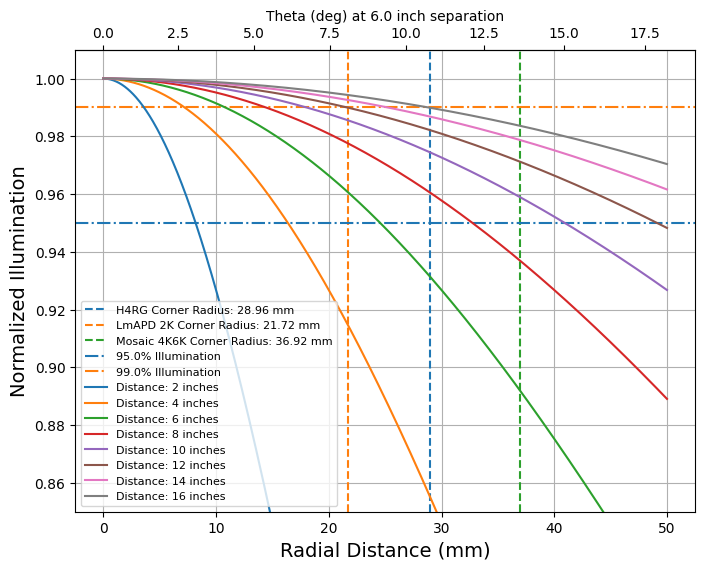

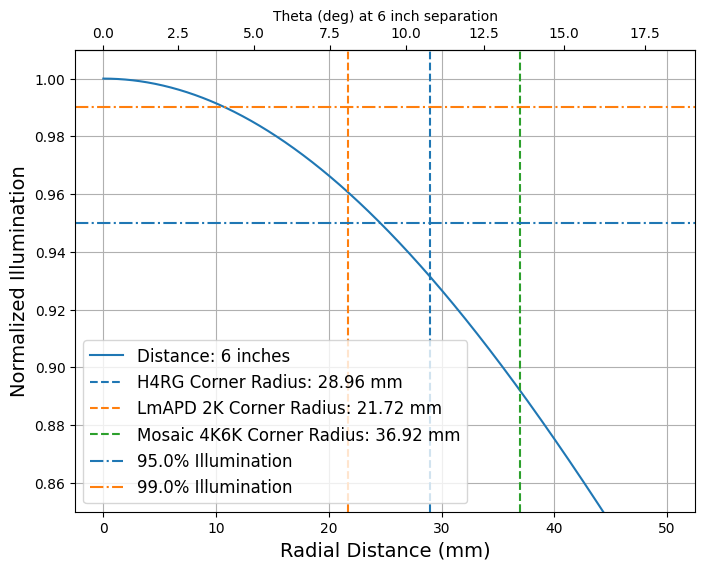

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

distances = np.arange(2, 17, 2) # distances in inches
print("Distances:", distances)

h4rg_r = np.sqrt((4*1024*0.010)**2 + (4*1024*0.010)**2)/2 # radius to corner in mm
lmapd_2k_r = np.sqrt((2048*0.015)**2 + (2048*0.015)**2)/2 # radius to corner in mm
mosaic_4k6k_r = np.sqrt((4*1024*0.01)**2 + (6*1024*0.01)**2)/2 # radius to corner in mm

r = np.linspace(0, 50, 1000) # radius values from 0 to corner
fig, ax = plt.subplots(figsize=(8,6))
color_iter = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

for radius, label in [
    (h4rg_r, f'H4RG Corner Radius: {h4rg_r:.2f} mm'),
    (lmapd_2k_r, f'LmAPD 2K Corner Radius: {lmapd_2k_r:.2f} mm'),
    (mosaic_4k6k_r, f'Mosaic 4K6K Corner Radius: {mosaic_4k6k_r:.2f} mm'),
]:
    ax.axvline(radius, color=next(color_iter), linestyle='--', label=label)

target_cutoffs = [0.95, 0.99]
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, target_cutoff in enumerate(target_cutoffs):
    color = color_cycle[i % len(color_cycle)]
    ax.axhline(target_cutoff, color=color, linestyle='-.', label=f'{target_cutoff*100:.1f}% Illumination')

for d in distances:
    d_mm = d * 25.4 # convert inches to mm
    theta = np.arctan2(r,d_mm) # angle in radians
    theta_deg = np.degrees(theta) # angle in degrees
    illumination_norm = np.cos(theta)**4 # normalized illumination

    ax.plot(r, illumination_norm, label=f'Distance: {d} inches')
    ax.legend(fontsize=12)
    ax.set_xlabel('Radial Distance (mm)', fontsize=14)
    ax.set_ylabel('Normalized Illumination', fontsize=14)

reference_d_mm = 6 * 25.4
forward = lambda radius_mm: np.degrees(np.arctan2(radius_mm, reference_d_mm))
inverse = lambda theta_deg: np.tan(np.radians(theta_deg)) * reference_d_mm
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.set_xlabel(f'Theta (deg) at {reference_d_mm/25.4:.1f} inch separation')
ax.legend(fontsize = 8)
ax.set_ylim(0.85, 1.01)
ax.grid()


# Single plot for fixed distance:
fixed_distance = 6 # inches
fixed_distance_mm = fixed_distance * 25.4
fig2, ax2 = plt.subplots(figsize=(8,6))
color_iter = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
theta = np.arctan2(r, fixed_distance_mm) # angle in radians
theta_deg = np.degrees(theta) # angle in degrees
illumination_norm = np.cos(theta)**4 # normalized illumination
ax2.plot(r, illumination_norm, label=f'Distance: {fixed_distance} inches')
# plot the detector corners
for radius, label in [
    (h4rg_r, f'H4RG Corner Radius: {h4rg_r:.2f} mm'),
    (lmapd_2k_r, f'LmAPD 2K Corner Radius: {lmapd_2k_r:.2f} mm'),
    (mosaic_4k6k_r, f'Mosaic 4K6K Corner Radius: {mosaic_4k6k_r:.2f} mm'),
]:
    ax2.axvline(radius, color=next(color_iter), linestyle='--', label=label)
target_cutoffs = [0.95, 0.99]
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, target_cutoff in enumerate(target_cutoffs):
    color = color_cycle[i % len(color_cycle)]
    # finer dashed line
    ax2.axhline(target_cutoff, color=color, linestyle='-.', label=f'{target_cutoff*100:.1f}% Illumination')
ax2.set_xlabel('Radial Distance (mm)', fontsize=14)
ax2.set_ylabel('Normalized Illumination', fontsize=14)
forward2 = lambda radius_mm: np.degrees(np.arctan2(radius_mm, fixed_distance_mm))
inverse2 = lambda theta_deg: np.tan(np.radians(theta_deg)) * fixed_distance_mm
secax2 = ax2.secondary_xaxis('top', functions=(forward2, inverse2))
secax2.set_xlabel(f'Theta (deg) at {fixed_distance} inch separation')
ax2.legend(fontsize=12)
ax2.grid()
ax2.set_ylim(0.85, 1.01)


Port fraction: 0.022
Sphere multiplier: 18.717
Wavelength: 400 nm, electrons per second on pixel: 6.78e-02 e-/s
Wavelength: 400 nm, predicted current: 13.21 nA, measured current: 0.17 nA, ratio (meas/pred): 0.01
Wavelength: 500 nm, electrons per second on pixel: 8.29e-02 e-/s
Wavelength: 500 nm, predicted current: 30.29 nA, measured current: 2.35 nA, ratio (meas/pred): 0.08
Wavelength: 600 nm, electrons per second on pixel: 8.23e-02 e-/s
Wavelength: 600 nm, predicted current: 38.24 nA, measured current: 3.18 nA, ratio (meas/pred): 0.08
Wavelength: 700 nm, electrons per second on pixel: 8.17e-02 e-/s
Wavelength: 700 nm, predicted current: 45.36 nA, measured current: 3.72 nA, ratio (meas/pred): 0.08
Wavelength: 800 nm, electrons per second on pixel: 9.09e-02 e-/s
Wavelength: 800 nm, predicted current: 57.17 nA, measured current: 4.45 nA, ratio (meas/pred): 0.08
Wavelength: 900 nm, electrons per second on pixel: 2.06e-01 e-/s
Wavelength: 900 nm, predicted current: 139.21 nA, measured curr

Text(0, 0.5, 'Flux Correction Factor (Measured/Predicted)')

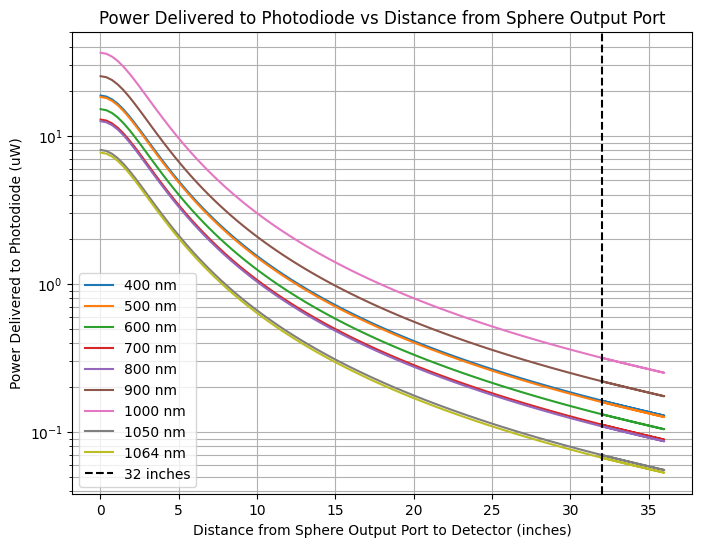

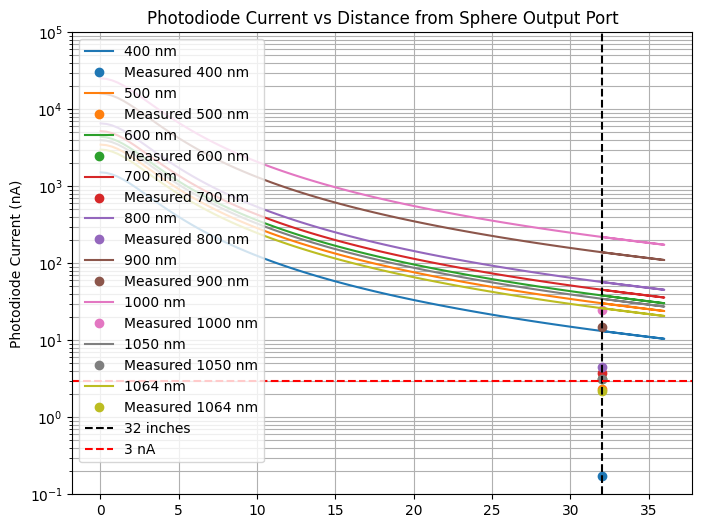

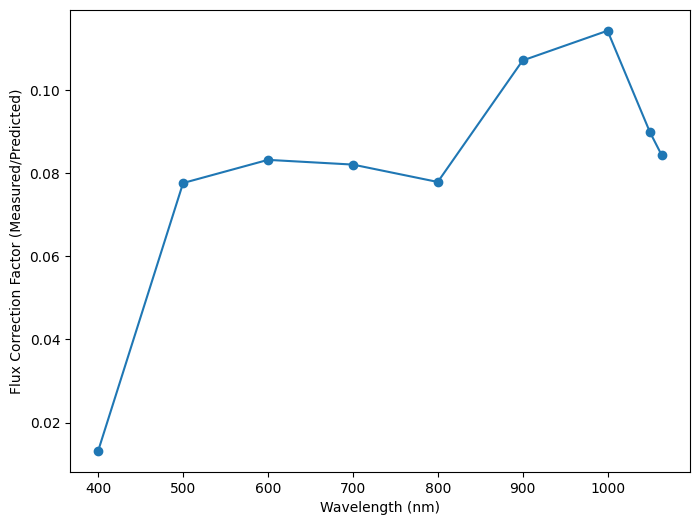

In [5]:
# Current test setup:
# Integrating sphere parameters

rho = 0.97  # reflectivity of sphere inner surface
dia_sphere_in = 20  # diameter of sphere in inches
dia_port_in = 6  # diameter of input port in inches

dia_sphere_mm = dia_sphere_in * 25.4  # convert to mm
dia_port_mm = dia_port_in * 25.4  # convert to mm

A_sphere_mm2 = np.pi * (dia_sphere_mm/2)**2  # cross-sectional area of sphere in mm^2

n_ports = 1  # number of ports (input + output)
f = (n_ports/4) * (dia_port_in/dia_sphere_in)**2  # port fraction
print(f"Port fraction: {f:.3f}")

M = rho / (1 - rho*(1-f)) # sphere multiplier
print(f"Sphere multiplier: {M:.3f}")

# Input Power: Phi_i
# Ls : Luminance of sphere
# As : Area of sphere (total)
# Ls = Phi_i * M / (pi*As)
# Phi_d : Power delivered to detector
# Ad : Area of detector
# theta : half-angle subtended by the sphere port as seen from the detector
# Phi_d = Ls * Ad * Pi * sin^2(theta)
selected_dist = 32
dist_detector_mm_arr = np.linspace(0.5, 36*25.4, 100)  # distance from output port to detector in mm
dist_detector_mm_arr = np.append(dist_detector_mm_arr, selected_dist*25.4)  # ensure selected distance is included
theta_arr = np.arctan((dia_port_mm/2) / dist_detector_mm_arr)  # half-angle in radians

# Photodiode detector parameters
# which photodiode

pds = ['Si_FDS100', 'MCT_TJT']
pd = 'Si_FDS1010'  # options: 'Si_FDS1010', 'Si_FDS100', 'InGaAs_FGA10', 'MCT_TJT'
ldls_fiber = "UVFIBERX-455"  # options: "UVFIBERX-455", "BBFIBERX-600"
A_pd_mm2 = photodiodes[pd].area_mm2  # area of photodiode active area in mm^2

A_detector_pixel_mm2 = .015**2  # area of detector in mm^2 (e.g., 15 um pixel)

fig_power, ax_power = plt.subplots(figsize=(8,6))
fig_current, ax_current = plt.subplots(figsize=(8,6))

# measured photodiode current at 32 in distance:
meas_wavelengths = [400,  500,  600,  700,  800,  900,  1000, 1050, 1064]
meas_current_nA = [0.175, 2.35, 3.18, 3.72, 4.45, 14.9, 25.1, 3.11, 2.20] # example measured currents in nA
flux_correction_factors = []

for wavelength in meas_wavelengths:
    # get spectral power at this wavelength
    ldls_raw_wavelength = ldls_spectral_power_dict[ldls_fiber]["wavelengths_nm"]
    ldls_raw_spectral_power = ldls_spectral_power_dict[ldls_fiber]["spectral_power_uW_per_nm"]

    spectral_power = np.interp(wavelength, ldls_raw_wavelength, ldls_raw_spectral_power)  # uW/nm
    #print(f"Wavelength: {wavelength} nm, Spectral Power: {spectral_power:.2f} uW/nm")

    spectral_bandwidth = 10  # nm, assume 10 nm bandwidth for calculation
    if wavelength == 1000:
        spectral_bandwidth = 25  # nm, wider bandwidth at 1000 nm

    phi_i = spectral_power * spectral_bandwidth  # total input power in uW

    Ls_arr = phi_i * M / (np.pi * A_sphere_mm2)  # sphere luminance in uW/mm^2/sr

    # Calculate power delivered to photodiode detector
    phi_d_arr_uW = Ls_arr * A_pd_mm2 * np.pi * (np.sin(theta_arr))**2  # power delivered to detector in uW

    # Calculate the power delivered to the detector pixel
    phi_d_pixel_arr_uW = Ls_arr * A_detector_pixel_mm2 * np.pi * (np.sin(theta_arr))**2  # power delivered to detector pixel in uW
    # photons_per_second = optical power (W) / energy per photon (J)
    e_photon_J = (h * c) / (wavelength * 1e-9)  # energy per photon in Joules (wavelength converted to m)
    photons_per_second = phi_d_pixel_arr_uW * 1e-6 / e_photon_J  # convert uW to W
    QE = 0.8  # assume 80% quantum efficiency
    electrons_per_second = photons_per_second * QE  # accounting for quantum efficiency
    print(f"Wavelength: {wavelength} nm, electrons per second on pixel: {electrons_per_second[0]:.2e} e-/s")


    # Calculate the photodiode response at this wavelength
    i_pd = (phi_d_arr_uW*1e-6)*photodiodes[pd].get_response(wavelength)  # A/W

    ax_power.plot(dist_detector_mm_arr/25.4, phi_d_arr_uW, label = f"{wavelength} nm")
    ax_current.plot(dist_detector_mm_arr/25.4, i_pd*1e9, label = f"{wavelength} nm")  # convert A to nA

    # plot the measured current on the same plot, match the color of the prior plot
    color = ax_current.get_lines()[-1].get_color()
    ax_current.plot([selected_dist], [meas_current_nA[meas_wavelengths.index(wavelength)]], 
                    'o', label=f"Measured {wavelength} nm", color=color)
    # calculate the ratio of measured to predicted current
    pred_current_nA = i_pd[dist_detector_mm_arr == selected_dist*25.4][0] * 1e9
    ratio = meas_current_nA[meas_wavelengths.index(wavelength)] / pred_current_nA
    print(f"Wavelength: {wavelength} nm, predicted current: {pred_current_nA:.2f} nA, measured current: {meas_current_nA[meas_wavelengths.index(wavelength)]:.2f} nA, ratio (meas/pred): {ratio:.2f}")
    flux_correction_factors.append(ratio)

ax_power.axvline(x=selected_dist, color='k', linestyle='--', label=f'{selected_dist} inches')
ax_power.set_xlabel("Distance from Sphere Output Port to Detector (inches)")
ax_power.set_ylabel("Power Delivered to Photodiode (uW)")
ax_power.set_title("Power Delivered to Photodiode vs Distance from Sphere Output Port")
ax_power.set_yscale('log')
ax_power.legend()
ax_power.grid(True, which = 'both')

ax_current.axvline(x=selected_dist, color='k', linestyle='--', label=f'{selected_dist} inches')
ax_current.axhline(y = 3.0, color='r', linestyle='--', label='3 nA')
ax_current.set_ylabel("Photodiode Current (nA)")
ax_current.set_title("Photodiode Current vs Distance from Sphere Output Port")
ax_current.set_yscale('log')
ax_current.set_ylim(0.1, 1e5)
ax_current.legend()
ax_current.grid(True, which = 'both')

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(meas_wavelengths, flux_correction_factors, 'o-')
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Flux Correction Factor (Measured/Predicted)")


Port fraction: 0.023
Sphere multiplier: 18.558
Dark current: 0.00 nA
Wavelength: 500 nm, electrons per second on pixel: 3.01e+00 e-/s
Wavelength: 500 nm, predicted current: 0.25 nA, measured current: 0.70 nA, ratio (meas/pred): 2.78
Wavelength: 600 nm, electrons per second on pixel: 2.99e+00 e-/s
Wavelength: 600 nm, predicted current: 0.34 nA, measured current: 1.03 nA, ratio (meas/pred): 2.99
Wavelength: 700 nm, electrons per second on pixel: 2.97e+00 e-/s
Wavelength: 700 nm, predicted current: 0.36 nA, measured current: 0.99 nA, ratio (meas/pred): 2.73
Wavelength: 800 nm, electrons per second on pixel: 3.31e+00 e-/s
Wavelength: 800 nm, predicted current: 0.45 nA, measured current: 1.05 nA, ratio (meas/pred): 2.36
Wavelength: 900 nm, electrons per second on pixel: 7.50e+00 e-/s
Wavelength: 900 nm, predicted current: 1.26 nA, measured current: 2.97 nA, ratio (meas/pred): 2.35
Wavelength: 1000 nm, electrons per second on pixel: 1.20e+01 e-/s
Wavelength: 1000 nm, predicted current: 2.12 

Text(0, 0.5, 'Flux Correction Factor (Measured/Predicted)')

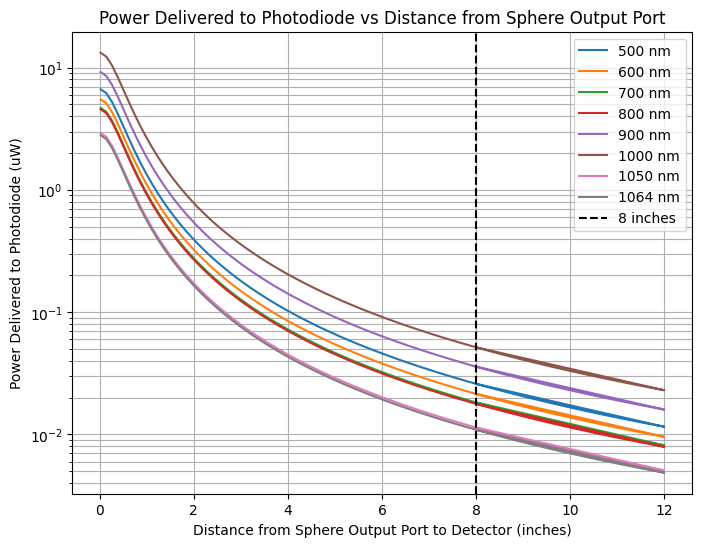

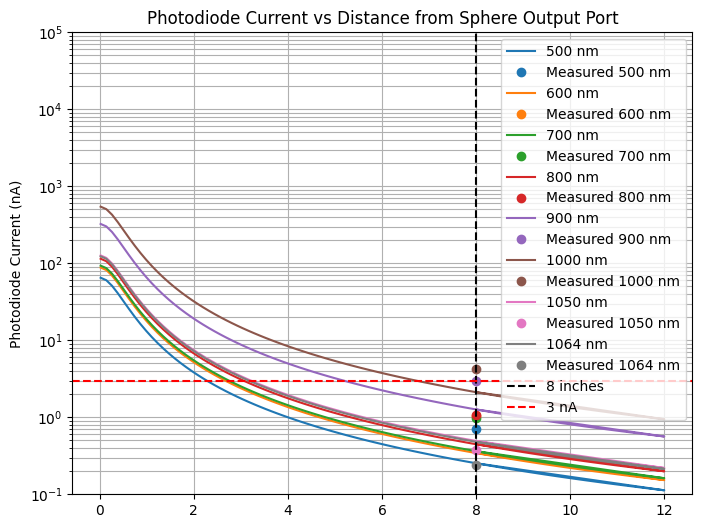

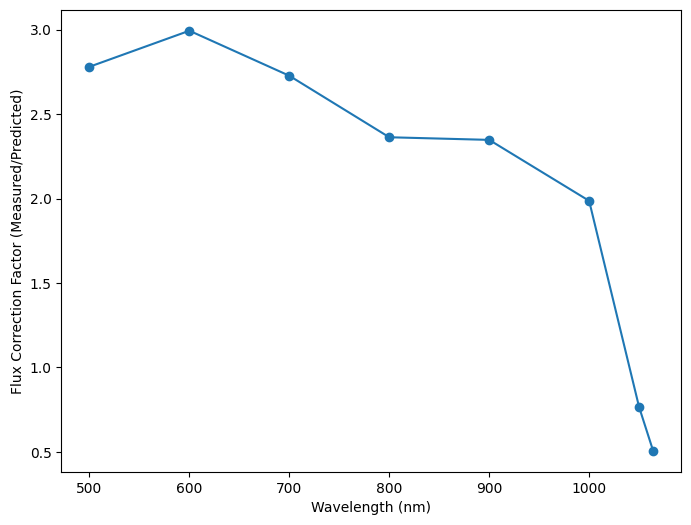

In [6]:
# Compare with measured data on little sphere
# Current test setup:
# Integrating sphere parameters

rho = 0.97  # reflectivity of sphere inner surface
dia_sphere_in = 3.3  # diameter of sphere in inches
dia_port_in = 1.0  # diameter of input port in inches

dia_sphere_mm = dia_sphere_in * 25.4  # convert to mm
dia_port_mm = dia_port_in * 25.4  # convert to mm

A_sphere_mm2 = np.pi * (dia_sphere_mm/2)**2  # cross-sectional area of sphere in mm^2

n_ports = 1  # number of ports (input + output)
f = (n_ports/4) * (dia_port_in/dia_sphere_in)**2  # port fraction
print(f"Port fraction: {f:.3f}")

M = rho / (1 - rho*(1-f)) # sphere multiplier
print(f"Sphere multiplier: {M:.3f}")

# Input Power: Phi_i
# Ls : Luminance of sphere
# As : Area of sphere (total)
# Ls = Phi_i * M / (pi*As)
# Phi_d : Power delivered to detector
# Ad : Area of detector
# theta : half-angle subtended by the sphere port as seen from the detector
# Phi_d = Ls * Ad * Pi * sin^2(theta)
selected_dist = 8
dist_detector_mm_arr = np.linspace(0.5, 12*25.4, 100)  # distance from output port to detector in mm
dist_detector_mm_arr = np.append(dist_detector_mm_arr, selected_dist*25.4)  # ensure selected distance is included
theta_arr = np.arctan((dia_port_mm/2) / dist_detector_mm_arr)  # half-angle in radians

# Photodiode detector parameters
# which photodiode

pd = 'Si_FD11A'  # options: 'Si_FDS1010', 'Si_FDS100', 'Si_FD11A', 'InGaAs_FGA10', 'MCT_TJT'
pd = 'MCT_TJT'
ldls_fiber = "UVFIBERX-455"  # options: "UVFIBERX-455", "BBFIBERX-600"

A_pd_mm2 = photodiodes[pd].area_mm2  # area of photodiode active area in mm^2

A_detector_pixel_mm2 = .015**2  # area of detector in mm^2 (e.g., 15 um pixel)

fig_power, ax_power = plt.subplots(figsize=(8,6))
fig_current, ax_current = plt.subplots(figsize=(8,6))

meas_current_nA_dark = 3.57E-12*1e9  # dark current in nA
print(f"Dark current: {meas_current_nA_dark:.2f} nA")
# measured photodiode current at 8 in distance:
meas_wavelengths = [400,   500,   600,   700,   800,   900,   1000,  1050, 1064]
meas_current_nA = [0.0081, 0.703, 1.027, .9897, 1.055, 2.966, 4.208, .377, 0.243] # example measured currents in nA
flux_correction_factors = []

#400 nm point is weird, ignore it for now
meas_wavelengths = meas_wavelengths[1:]
meas_current_nA = meas_current_nA[1:]

# throughput loss correction factor
throughput_correction = 0.1  # measured throughput loss factor

for wavelength in meas_wavelengths:

    # get spectral power at this wavelength
    ldls_raw_wavelength = ldls_spectral_power_dict[ldls_fiber]["wavelengths_nm"]
    ldls_raw_spectral_power = ldls_spectral_power_dict[ldls_fiber]["spectral_power_uW_per_nm"]
    
    spectral_power = np.interp(wavelength, ldls_raw_wavelength, ldls_raw_spectral_power)  # uW/nm
    #print(f"Wavelength: {wavelength} nm, Spectral Power: {spectral_power:.2f} uW/nm")

    spectral_bandwidth = 10  # nm, assume 10 nm bandwidth for calculation
    if wavelength == 1000:
        spectral_bandwidth = 25  # nm, wider bandwidth at 1000 nm

    phi_i = spectral_power * spectral_bandwidth  # total input power in uW

    Ls_arr = phi_i * M / (np.pi * A_sphere_mm2)  # sphere luminance in uW/mm^2/sr

    # Calculate power delivered to photodiode detector
    phi_d_arr_uW = Ls_arr * A_pd_mm2 * np.pi * (np.sin(theta_arr))**2  # power delivered to detector in uW

    # Calculate the power delivered to the detector pixel
    phi_d_pixel_arr_uW = Ls_arr * A_detector_pixel_mm2 * np.pi * (np.sin(theta_arr))**2  # power delivered to detector pixel in uW
    # photons_per_second = optical power (W) / energy per photon (J)
    e_photon_J = (h * c) / (wavelength * 1e-9)  # energy per photon in Joules (wavelength converted to m)
    photons_per_second = phi_d_pixel_arr_uW * 1e-6 / e_photon_J  # convert uW to W
    QE = 0.8  # assume 80% quantum efficiency
    electrons_per_second = photons_per_second * QE  # accounting for quantum efficiency
    print(f"Wavelength: {wavelength} nm, electrons per second on pixel: {electrons_per_second[0]:.2e} e-/s")


    # Calculate the photodiode response at this wavelength
    i_pd = (phi_d_arr_uW*1e-6)*photodiodes[pd].get_response(wavelength) * throughput_correction  # A/W

    ax_power.plot(dist_detector_mm_arr/25.4, phi_d_arr_uW, label = f"{wavelength} nm")
    ax_current.plot(dist_detector_mm_arr/25.4, i_pd*1e9, label = f"{wavelength} nm")  # convert A to nA

    # plot the measured current on the same plot, match the color of the prior plot
    color = ax_current.get_lines()[-1].get_color()
    ax_current.plot([selected_dist], [meas_current_nA[meas_wavelengths.index(wavelength)]], 
                    'o', label=f"Measured {wavelength} nm", color=color)
    # calculate the ratio of measured to predicted current
    pred_current_nA = i_pd[dist_detector_mm_arr == selected_dist*25.4][0] * 1e9
    ratio = meas_current_nA[meas_wavelengths.index(wavelength)] / pred_current_nA
    print(f"Wavelength: {wavelength} nm, predicted current: {pred_current_nA:.2f} nA, measured current: {meas_current_nA[meas_wavelengths.index(wavelength)]:.2f} nA, ratio (meas/pred): {ratio:.2f}")
    flux_correction_factors.append(ratio)

ax_power.axvline(x=selected_dist, color='k', linestyle='--', label=f'{selected_dist} inches')
ax_power.set_xlabel("Distance from Sphere Output Port to Detector (inches)")
ax_power.set_ylabel("Power Delivered to Photodiode (uW)")
ax_power.set_title("Power Delivered to Photodiode vs Distance from Sphere Output Port")
ax_power.set_yscale('log')
ax_power.legend()
ax_power.grid(True, which = 'both')

ax_current.axvline(x=selected_dist, color='k', linestyle='--', label=f'{selected_dist} inches')
ax_current.axhline(y = 3.0, color='r', linestyle='--', label='3 nA')
ax_current.set_ylabel("Photodiode Current (nA)")
ax_current.set_title("Photodiode Current vs Distance from Sphere Output Port")
ax_current.set_yscale('log')
ax_current.set_ylim(0.1, 1e5)
ax_current.legend()
ax_current.grid(True, which = 'both')

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(meas_wavelengths, flux_correction_factors, 'o-')
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Flux Correction Factor (Measured/Predicted)")
